In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegressionModel
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = SparkSession.builder \
    .appName("FinalTestEvaluation") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")

DATA_DIR = '../data'
TEST_FEAT_DIR = os.path.join(DATA_DIR, 'test_feat')
MODEL_PATH = os.path.join(DATA_DIR, 'models', 'best_lr') 

26/05/05 20:30:19 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [3]:
# Load the pre-built test features — the real 10% test split
# This was saved by notebook 02, preprocessed consistently with train/val
test_feat = spark.read.parquet(TEST_FEAT_DIR)

print(f"Test rows : {test_feat.count():,}")
test_feat.groupBy("Sentiment", "label").count().orderBy("label").show()

Test rows : 38,392
+---------+-----+-----+
|Sentiment|label|count|
+---------+-----+-----+
| negative|    0| 5363|
|  neutral|    1| 2798|
| positive|    2|30231|
+---------+-----+-----+



In [4]:
model = LogisticRegressionModel.load(MODEL_PATH)
print(f"Model loaded from {MODEL_PATH}")

test_preds = model.transform(test_feat)
test_preds.cache()

Model loaded from ../data/models/best_lr


DataFrame[Id: int, ProductId: string, UserId: string, Score: string, Time: string, Sentiment: string, label: int, features: vector, classWeight: double, rawPrediction: vector, probability: vector, prediction: double]

In [5]:
def ev(preds, metric, label=None):
    kwargs = dict(predictionCol='prediction', labelCol='label', metricName=metric)
    if label is not None:
        kwargs['metricLabel'] = label
    return MulticlassClassificationEvaluator(**kwargs).evaluate(preds)

f1  = ev(test_preds, 'f1')
acc = ev(test_preds, 'accuracy')

print(f"{'='*50}")
print(f"  FINAL TEST SET RESULTS (10% — never seen before)")
print(f"{'='*50}")
print(f"  Weighted F1 : {f1:.4f}")
print(f"  Accuracy    : {acc:.4f}")

26/05/05 20:30:40 WARN DAGScheduler: Broadcasting large task binary with size 1072.8 KiB
26/05/05 20:30:41 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/05/05 20:30:42 WARN DAGScheduler: Broadcasting large task binary with size 1089.8 KiB


  FINAL TEST SET RESULTS (10% — never seen before)
  Weighted F1 : 0.8013
  Accuracy    : 0.7815


26/05/05 20:30:42 WARN DAGScheduler: Broadcasting large task binary with size 1089.8 KiB


In [6]:
print(f"\n  {'─'*46}")
rows = []
for i, cls in enumerate(['negative', 'neutral', 'positive']):
    p = ev(test_preds, 'precisionByLabel', i)
    r = ev(test_preds, 'recallByLabel',    i)
    f = ev(test_preds, 'fMeasureByLabel',  i)
    print(f"  {cls:>8s}  P:{p:.4f}  R:{r:.4f}  F1:{f:.4f}")
    rows.append({'class': cls, 'precision': p, 'recall': r, 'f1': f})


  ──────────────────────────────────────────────


26/05/05 20:30:52 WARN DAGScheduler: Broadcasting large task binary with size 1089.8 KiB
26/05/05 20:30:52 WARN DAGScheduler: Broadcasting large task binary with size 1089.8 KiB
26/05/05 20:30:53 WARN DAGScheduler: Broadcasting large task binary with size 1089.8 KiB


  negative  P:0.5475  R:0.6811  F1:0.6071


26/05/05 20:30:53 WARN DAGScheduler: Broadcasting large task binary with size 1089.8 KiB
26/05/05 20:30:53 WARN DAGScheduler: Broadcasting large task binary with size 1089.8 KiB
26/05/05 20:30:53 WARN DAGScheduler: Broadcasting large task binary with size 1089.8 KiB
26/05/05 20:30:53 WARN DAGScheduler: Broadcasting large task binary with size 1089.8 KiB
26/05/05 20:30:53 WARN DAGScheduler: Broadcasting large task binary with size 1089.8 KiB


   neutral  P:0.2177  R:0.3649  F1:0.2727
  positive  P:0.9371  R:0.8379  F1:0.8847


26/05/05 20:30:53 WARN DAGScheduler: Broadcasting large task binary with size 1089.8 KiB


/home/regisx001/Analyse-avis-clients-temps-produits-Amazon/.venv/lib/python3.10/site-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
26/05/05 20:31:56 WARN DAGScheduler: Broadcasting large task binary with size 1082.2 KiB
26/05/05 20:31:56 WARN DAGScheduler: Broadcasting large task binary with size 1094.6 KiB


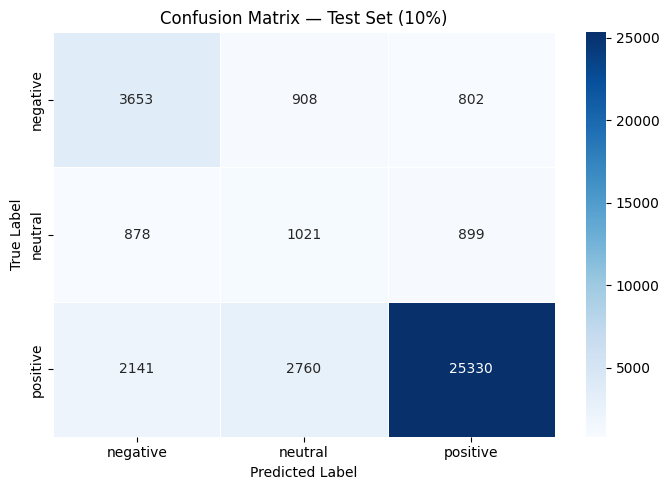

Saved → ../reports/confusion_matrix.png


In [9]:
from pyspark.mllib.evaluation import MulticlassMetrics

preds_and_labels = test_preds.select("prediction", "label") \
    .rdd.map(lambda r: (float(r.prediction), float(r.label)))

metrics = MulticlassMetrics(preds_and_labels)
cm = metrics.confusionMatrix().toArray()

labels = ['negative', 'neutral', 'positive']
cm_df = pd.DataFrame(cm.astype(int), index=labels, columns=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar=True)
plt.title('Confusion Matrix — Test Set (10%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../figures/reports/confusion_matrix.png', dpi=150)
plt.show()
print("Saved → ../reports/confusion_matrix.png")

In [ ]:
# Compare validation results (from notebook 04) vs test results
# TODO edits later
comparison = pd.DataFrame({
    'Class':     ['negative', 'neutral', 'positive', 'OVERALL'],
    'Val P':     [0.5461, 0.2251, 0.9365, '—'],
    'Val R':     [0.6800, 0.3821, 0.8345, '—'],
    'Val F1':    [0.6057, 0.2833, 0.8826, 0.7997],
    'Test P':    ['?', '?', '?', '—'],   # fill after running
    'Test R':    ['?', '?', '?', '—'],
    'Test F1':   ['?', '?', '?', '?'],
})
print(comparison.to_string(index=False))

   Class   Val P   Val R  Val F1 Test P Test R Test F1
negative  0.5461    0.68  0.6057      ?      ?       ?
 neutral  0.2251  0.3821  0.2833      ?      ?       ?
positive  0.9365  0.8345  0.8826      ?      ?       ?
 OVERALL       —       —  0.7997      —      —       ?
